# LLM disclosure risk score — analysis notebook

This notebook covers:
1. **LLM evaluation results** — per-provider DRS, REAL-label bias, confidence
2. **Human annotation results** — 2 annotators (HA1, HA2), per-annotator DRS, pooled comparison vs LLM


In [1]:
import json, glob, os
import hashlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from pathlib import Path
%matplotlib inline
from IPython.display import display

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT        = Path("/Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026")
results_dir = str(ROOT / "results")
fig_dir     = results_dir

# ── Global plot style ─────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.size': 20,        'font.weight': 'bold',
    'axes.labelsize': 20,   'axes.labelweight': 'bold',
    'axes.titlesize': 20,   'axes.titleweight': 'bold',
    'xtick.labelsize': 18,  'ytick.labelsize': 18,
    'legend.fontsize': 17,
})

METHODS       = ['ctgan', 'tvae', 'gaussian_copula']
METHOD_LABELS = {'ctgan': 'CTGAN', 'tvae': 'TVAE', 'gaussian_copula': 'Gaussian Copula'}
CONDS         = ['C1', 'C2']
DATASETS      = ['adult', 'census']
colors_cond   = {'C1': '#f59e0b', 'C2': '#2563eb'}

def stable_int_seed(*parts):
    # Stable cross-session seed: avoids Python hash randomization drift.
    joined = '||'.join(str(p) for p in parts)
    digest = hashlib.sha256(joined.encode('utf-8')).hexdigest()
    return int(digest[:8], 16)

# Short display names used in plot labels
MODEL_DISPLAY = {
    'Groq (LLaMA-3.1-8b)': 'Groq (LLaMA)',
    'Google (Gemini-2.5-Flash)': 'Gemini',
}

print("Setup complete.")

Setup complete.


## 1. LLM evaluation results

Loading all JSONL verdict files from `results/`. Computing accuracy, DRS and REAL-label bias per provider, model, synthesis method and condition.

In [2]:
# Unified LLM result loading (single source of truth)
VALID_LABELS = {'REAL', 'SYNTHETIC'}
APPROVED_MODELS = {
    ('groq', 'llama-3.1-8b-instant'): 'Groq (LLaMA-3.1-8b)',
    ('google', 'gemini-2.5-flash'): 'Google (Gemini-2.5-Flash)'
}
EXCLUDE_PATH_MARKERS = ('archive_invalid', '/res1/')
FAIR_MIN_N = 8  # Minimum per-cell valid trials required per model for fair comparison

records = []
invalid_lines = 0
excluded_model_lines = 0

for f in sorted(glob.glob(f'{results_dir}/**/*.jsonl', recursive=True)):
    norm_f = f.replace('\\', '/')
    if any(marker in norm_f for marker in EXCLUDE_PATH_MARKERS):
        continue

    dataset = 'census' if '/census/' in norm_f else 'adult'

    with open(f) as fp:
        for line in fp:
            try:
                d = json.loads(line)
            except Exception:
                invalid_lines += 1
                continue

            if d.get('predicted_label') not in VALID_LABELS:
                invalid_lines += 1
                continue

            provider = d.get('provider', '?')
            model = d.get('model', '?')
            model_key = (provider, model)
            if model_key not in APPROVED_MODELS:
                excluded_model_lines += 1
                continue

            conf = d.get('confidence', np.nan)
            conf = conf if isinstance(conf, (int, float)) and conf > 0 else np.nan

            records.append({
                'dataset': dataset,
                'provider': provider,
                'model': model,
                'provider_label': APPROVED_MODELS[model_key],
                'method': d.get('synthetic_method', '?'),
                'condition': d.get('condition', '?'),
                'true_label': d.get('true_label', '?'),
                'predicted_label': d.get('predicted_label', '?'),
                'correct': bool(d.get('correct', False)),
                'confidence': conf,
            })

llm_df = pd.DataFrame(records)
if llm_df.empty:
    raise RuntimeError('No valid approved LLM records found after filtering.')


def compute_cell_metrics(df):
    real = df[df['true_label'] == 'REAL']
    syn = df[df['true_label'] == 'SYNTHETIC']
    p_real = real['correct'].mean() * 100 if len(real) else np.nan
    p_syn = syn['correct'].mean() * 100 if len(syn) else np.nan
    drs = min(p_real, p_syn) if (not np.isnan(p_real) and not np.isnan(p_syn)) else np.nan
    return pd.Series({
        'N': len(df),
        'N_real': len(real),
        'N_syn': len(syn),
        'Accuracy': df['correct'].mean() * 100,
        'p_real_correct': p_real,
        'p_syn_correct': p_syn,
        'DRS': drs,
        'Pred_REAL_rate': (df['predicted_label'] == 'REAL').mean() * 100,
        'Avg_conf': df['confidence'].mean(),
    })


# Keep compatibility across pandas versions while avoiding groupby-apply deprecation warnings.
def grouped_metrics(df, group_cols):
    gb = df.groupby(group_cols, as_index=False)
    try:
        return gb.apply(compute_cell_metrics, include_groups=False).reset_index(drop=True)
    except TypeError:
        return gb.apply(compute_cell_metrics).reset_index(drop=True)


cell_stats = grouped_metrics(llm_df, ['dataset', 'provider_label', 'method', 'condition'])
model_stats = grouped_metrics(llm_df, ['provider_label'])

print('LLM records loaded:', len(llm_df))
print('Invalid/error lines discarded:', invalid_lines)
print('Valid but excluded model lines discarded:', excluded_model_lines)
print('\nModels in analysis:')
print(model_stats[['provider_label', 'N', 'DRS', 'Accuracy', 'Pred_REAL_rate', 'Avg_conf']].round(1).to_string(index=False))

print('\nCell-level stats (dataset × model × method × condition):')
display(cell_stats[['dataset', 'provider_label', 'method', 'condition', 'N', 'N_real', 'N_syn', 'DRS', 'Accuracy', 'Avg_conf']].round(1))

LLM records loaded: 451
Invalid/error lines discarded: 409
Valid but excluded model lines discarded: 0

Models in analysis:
           provider_label     N  DRS  Accuracy  Pred_REAL_rate  Avg_conf
Google (Gemini-2.5-Flash) 104.0 83.7      92.3            60.6      95.5
      Groq (LLaMA-3.1-8b) 347.0 20.2      51.6            81.3      83.8

Cell-level stats (dataset × model × method × condition):


,dataset,provider_label,method,condition,N,N_real,N_syn,DRS,Accuracy,Avg_conf
0,adult,Google (Gemini-2.5-Flash),ctgan,C1,12.0,6.0,6.0,100.0,100.0,96.5
1,adult,Google (Gemini-2.5-Flash),ctgan,C2,12.0,8.0,4.0,100.0,100.0,97.0
2,adult,Google (Gemini-2.5-Flash),gaussian_copula,C1,4.0,2.0,2.0,100.0,100.0,96.5
3,adult,Google (Gemini-2.5-Flash),tvae,C1,11.0,6.0,5.0,100.0,100.0,95.0
4,adult,Google (Gemini-2.5-Flash),tvae,C2,11.0,6.0,5.0,100.0,100.0,96.6
5,adult,Groq (LLaMA-3.1-8b),ctgan,C1,50.0,25.0,25.0,0.0,50.0,85.0
6,adult,Groq (LLaMA-3.1-8b),ctgan,C2,50.0,25.0,25.0,0.0,50.0,85.0
7,adult,Groq (LLaMA-3.1-8b),gaussian_copula,C1,50.0,25.0,25.0,0.0,50.0,85.0
8,adult,Groq (LLaMA-3.1-8b),gaussian_copula,C2,50.0,25.0,25.0,0.0,50.0,82.5
9,adult,Groq (LLaMA-3.1-8b),tvae,C1,46.0,22.0,24.0,0.0,47.8,85.0


In [3]:
# Reproducibility metadata for this analysis run
from datetime import datetime, timezone

included_jsonl = []
for f in sorted(glob.glob(f'{results_dir}/**/*.jsonl', recursive=True)):
    norm_f = f.replace('\\', '/')
    if any(marker in norm_f for marker in EXCLUDE_PATH_MARKERS):
        continue
    included_jsonl.append(norm_f)

print('Run timestamp (UTC):', datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S %Z'))
print('Included models:')
for (prov, mod), label in APPROVED_MODELS.items():
    print(f'  - {prov} / {mod}  ->  {label}')
print('Valid labels:', sorted(VALID_LABELS))
print('Excluded path markers:', EXCLUDE_PATH_MARKERS)
print('Fairness threshold:', FAIR_MIN_N)
print('Included JSONL files:', len(included_jsonl))
print('First 10 files:')
for p in included_jsonl[:10]:
    print('  ', p)
if len(included_jsonl) > 10:
    print(f'  ... and {len(included_jsonl) - 10} more')

Run timestamp (UTC): 2026-05-31 22:00:00 UTC
Included models:
  - groq / llama-3.1-8b-instant  ->  Groq (LLaMA-3.1-8b)
  - google / gemini-2.5-flash  ->  Google (Gemini-2.5-Flash)
Valid labels: ['REAL', 'SYNTHETIC']
Excluded path markers: ('archive_invalid', '/res1/')
Fairness threshold: 8
Included JSONL files: 17
First 10 files:
   /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/adult/llm_results_ctgan_google_20260514_114319.jsonl
   /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/adult/llm_results_ctgan_google_20260514_115609.jsonl
   /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/adult/llm_results_ctgan_groq_20260514_130005.jsonl
   /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/adult/llm_results_gaussian_copula_google_20260514_115447.jsonl
   /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/adult/llm_results_

In [4]:
# Fairness diagnostics for cross-model comparisons
coverage = (
    cell_stats
    .pivot_table(
        index=['dataset', 'method', 'condition'],
        columns='provider_label',
        values='N',
        aggfunc='sum',
        fill_value=0,
    )
    .reset_index()
)

for label in APPROVED_MODELS.values():
    if label not in coverage.columns:
        coverage[label] = 0

model_cols = list(APPROVED_MODELS.values())
coverage['N_min_across_models'] = coverage[model_cols].min(axis=1)
coverage['fair_cell'] = coverage['N_min_across_models'] >= FAIR_MIN_N

print(f'Fairness threshold: N >= {FAIR_MIN_N} per model per cell')
print(f'Fair cells: {int(coverage["fair_cell"].sum())}/{len(coverage)}')
print()
print('Coverage table (dataset × method × condition):')
display(coverage[['dataset', 'method', 'condition'] + model_cols + ['N_min_across_models', 'fair_cell']])

fair_keys = coverage.loc[coverage['fair_cell'], ['dataset', 'method', 'condition']]
cell_stats_fair = cell_stats.merge(fair_keys, on=['dataset', 'method', 'condition'], how='inner')

print('Cell-level metrics on fair subset only:')
display(cell_stats_fair[['dataset', 'provider_label', 'method', 'condition', 'N', 'DRS', 'Accuracy', 'Avg_conf']].round(1))

Fairness threshold: N >= 8 per model per cell
Fair cells: 10/12

Coverage table (dataset × method × condition):


provider_label,dataset,method,condition,Groq (LLaMA-3.1-8b),Google (Gemini-2.5-Flash),N_min_across_models,fair_cell
0,adult,ctgan,C1,50.0,12.0,12.0,True
1,adult,ctgan,C2,50.0,12.0,12.0,True
2,adult,gaussian_copula,C1,50.0,4.0,4.0,False
3,adult,gaussian_copula,C2,50.0,0.0,0.0,False
4,adult,tvae,C1,46.0,11.0,11.0,True
5,adult,tvae,C2,41.0,11.0,11.0,True
6,census,ctgan,C1,10.0,9.0,9.0,True
7,census,ctgan,C2,10.0,10.0,10.0,True
8,census,gaussian_copula,C1,10.0,8.0,8.0,True
9,census,gaussian_copula,C2,10.0,9.0,9.0,True


Cell-level metrics on fair subset only:


,dataset,provider_label,method,condition,N,DRS,Accuracy,Avg_conf
0,adult,Google (Gemini-2.5-Flash),ctgan,C1,12.0,100.0,100.0,96.5
1,adult,Google (Gemini-2.5-Flash),ctgan,C2,12.0,100.0,100.0,97.0
2,adult,Google (Gemini-2.5-Flash),tvae,C1,11.0,100.0,100.0,95.0
3,adult,Google (Gemini-2.5-Flash),tvae,C2,11.0,100.0,100.0,96.6
4,adult,Groq (LLaMA-3.1-8b),ctgan,C1,50.0,0.0,50.0,85.0
5,adult,Groq (LLaMA-3.1-8b),ctgan,C2,50.0,0.0,50.0,85.0
6,adult,Groq (LLaMA-3.1-8b),tvae,C1,46.0,0.0,47.8,85.0
7,adult,Groq (LLaMA-3.1-8b),tvae,C2,41.0,26.3,65.9,82.7
8,census,Google (Gemini-2.5-Flash),ctgan,C1,9.0,100.0,100.0,95.0
9,census,Google (Gemini-2.5-Flash),ctgan,C2,10.0,0.0,50.0,96.2


In [5]:
# Optional strict matching: downsample each model to equal N per fair cell
# This avoids changing provider data collection while enforcing perfectly matched Ns in analysis.
MATCHED_RANDOM_SEED = 2026

if 'cell_stats_fair' not in globals() or cell_stats_fair.empty:
    raise RuntimeError('Run fairness diagnostics cell first (cell_stats_fair is missing).')

models = list(APPROVED_MODELS.values())
if len(models) != 2:
    raise RuntimeError('Matched downsampling currently expects exactly 2 approved models.')

cell_keys = cell_stats_fair[['dataset', 'method', 'condition']].drop_duplicates()
matched_parts = []

for _, k in cell_keys.iterrows():
    ds, m, c = k['dataset'], k['method'], k['condition']

    a = llm_df[(llm_df['dataset'] == ds) & (llm_df['method'] == m) & (llm_df['condition'] == c) & (llm_df['provider_label'] == models[0])]
    b = llm_df[(llm_df['dataset'] == ds) & (llm_df['method'] == m) & (llm_df['condition'] == c) & (llm_df['provider_label'] == models[1])]

    n_match = min(len(a), len(b))
    if n_match <= 0:
        continue

    # Deterministic per-cell seed for reproducibility
    cell_seed = stable_int_seed(MATCHED_RANDOM_SEED, ds, m, c)
    matched_parts.append(a.sample(n=n_match, random_state=cell_seed))
    matched_parts.append(b.sample(n=n_match, random_state=cell_seed + 1))

llm_df_matched = pd.concat(matched_parts, ignore_index=True)

cell_stats_matched = grouped_metrics(llm_df_matched, ['dataset', 'provider_label', 'method', 'condition'])
model_stats_matched = grouped_metrics(llm_df_matched, ['provider_label'])

matched_cov = (
    cell_stats_matched
    .pivot_table(
        index=['dataset', 'method', 'condition'],
        columns='provider_label',
        values='N',
        aggfunc='sum',
        fill_value=0,
    )
    .reset_index()
)
matched_cov['matched_equal_N'] = matched_cov[models[0]] == matched_cov[models[1]]

print('Matched sample mode enabled.')
print(f'Rows in matched dataset: {len(llm_df_matched)}')
print('Per-model totals after matching:')
display(model_stats_matched[['provider_label', 'N', 'DRS', 'Accuracy', 'Pred_REAL_rate', 'Avg_conf']].round(1))

print('Per-cell matched coverage check:')
display(matched_cov)

# Shared switch used by downstream cells
LLM_COMPARISON_MODE = 'matched'

Matched sample mode enabled.
Rows in matched dataset: 200
Per-model totals after matching:


,provider_label,N,DRS,Accuracy,Pred_REAL_rate,Avg_conf
0,Google (Gemini-2.5-Flash),100.0,83.0,92.0,61.0,95.4
1,Groq (LLaMA-3.1-8b),100.0,40.0,45.0,46.0,82.8


Per-cell matched coverage check:


provider_label,dataset,method,condition,Google (Gemini-2.5-Flash),Groq (LLaMA-3.1-8b),matched_equal_N
0,adult,ctgan,C1,12.0,12.0,True
1,adult,ctgan,C2,12.0,12.0,True
2,adult,tvae,C1,11.0,11.0,True
3,adult,tvae,C2,11.0,11.0,True
4,census,ctgan,C1,9.0,9.0,True
5,census,ctgan,C2,10.0,10.0,True
6,census,gaussian_copula,C1,8.0,8.0,True
7,census,gaussian_copula,C2,9.0,9.0,True
8,census,tvae,C1,9.0,9.0,True
9,census,tvae,C2,9.0,9.0,True


Saved: /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/fig_drs_seed_stability_ci.pdf


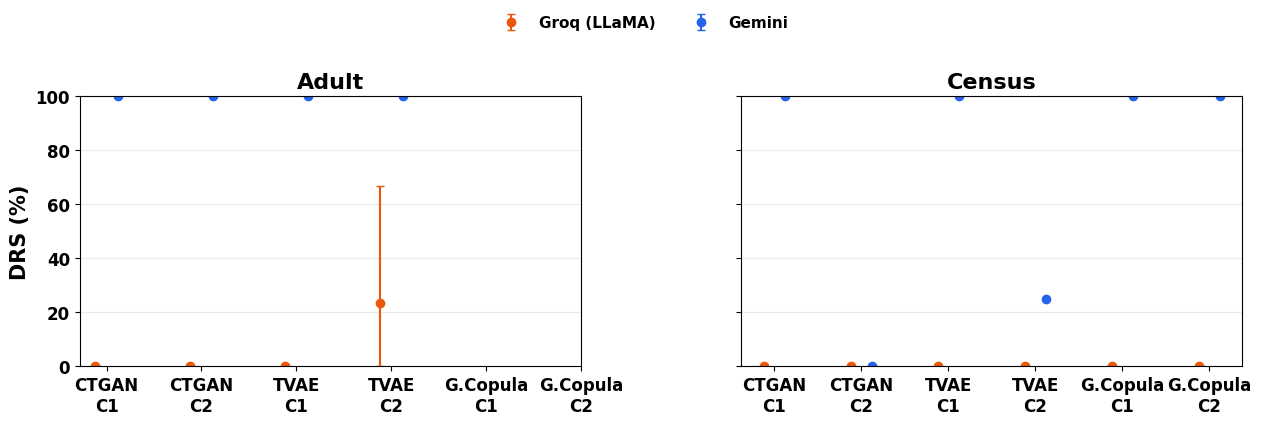

In [6]:
# ── Seed stability for matched-N DRS: 95% CI whiskers across random seeds ──────
# Uses whichever precomputed matched-seed stability table is available in kernel state.
# If missing, recomputes matched-cell DRS over a 50-seed sweep.

if not ('llm_df_matched' in globals() and LLM_COMPARISON_MODE == 'matched'):
    print('Skipping seed-stability plot because LLM_COMPARISON_MODE is not matched.')
else:
    candidate_tables = []
    for name in ['seed_stability_by_model', 'seed_cell_summary', 'seed_cell_stats']:
        if name in globals() and isinstance(globals()[name], pd.DataFrame) and not globals()[name].empty:
            candidate_tables.append(globals()[name].copy())

    if not candidate_tables:
        # Recompute when prior seed tables are not in kernel state.
        seed_stats_parts = []
        seed_values = list(range(1000, 1050))

        cell_keys = cell_stats_fair[['dataset', 'method', 'condition']].drop_duplicates()
        model_labels = list(APPROVED_MODELS.values())

        for seed in seed_values:
            matched_parts_seed = []
            for _, k in cell_keys.iterrows():
                ds, m, c = k['dataset'], k['method'], k['condition']

                a = llm_df[(llm_df['dataset'] == ds) & (llm_df['method'] == m) & (llm_df['condition'] == c) & (llm_df['provider_label'] == model_labels[0])]
                b = llm_df[(llm_df['dataset'] == ds) & (llm_df['method'] == m) & (llm_df['condition'] == c) & (llm_df['provider_label'] == model_labels[1])]

                n_match = min(len(a), len(b))
                if n_match <= 0:
                    continue

                rs_a = stable_int_seed(seed, ds, m, c, model_labels[0])
                rs_b = stable_int_seed(seed, ds, m, c, model_labels[1])
                matched_parts_seed.append(a.sample(n=n_match, random_state=rs_a))
                matched_parts_seed.append(b.sample(n=n_match, random_state=rs_b))

            if not matched_parts_seed:
                continue

            llm_df_seed = pd.concat(matched_parts_seed, ignore_index=True)
            cell_seed = grouped_metrics(llm_df_seed, ['dataset', 'provider_label', 'method', 'condition'])[
                ['dataset', 'provider_label', 'method', 'condition', 'DRS']
            ].copy()
            cell_seed['seed'] = seed
            seed_stats_parts.append(cell_seed)

        if not seed_stats_parts:
            print('Skipping seed-stability plot: failed to compute seed-sweep summaries.')
            seed_summary = None
        else:
            seed_cell_stats = pd.concat(seed_stats_parts, ignore_index=True)
            seed_summary = (
                seed_cell_stats
                .groupby(['dataset', 'provider_label', 'method', 'condition'], as_index=False)['DRS']
                .agg(mean='mean', q025=lambda x: np.quantile(x, 0.025), q975=lambda x: np.quantile(x, 0.975))
            )
    else:
        seed_summary = None
        for cand in candidate_tables:
            cols = set(cand.columns)
            if not {'dataset', 'provider_label', 'method', 'condition'}.issubset(cols):
                continue

            mean_col = next((c for c in ['mean', 'DRS_mean', 'drs_mean'] if c in cols), None)
            lo_col = next((c for c in ['q025', 'DRS_q025', 'drs_q025', 'ci_low', 'DRS_ci_low', 'drs_ci_low'] if c in cols), None)
            hi_col = next((c for c in ['q975', 'DRS_q975', 'drs_q975', 'ci_high', 'DRS_ci_high', 'drs_ci_high'] if c in cols), None)

            if mean_col and lo_col and hi_col:
                seed_summary = cand.rename(columns={mean_col: 'mean', lo_col: 'q025', hi_col: 'q975'})
                break

    if seed_summary is None:
        print('Skipping seed-stability plot: could not construct seed summary table.')
    else:
        combo_order = [(m, c) for m in METHODS for c in CONDS]
        method_short = {'ctgan': 'CTGAN', 'tvae': 'TVAE', 'gaussian_copula': 'G.Copula'}
        x_labels = [f"{method_short.get(m, METHOD_LABELS[m])}\n{c}" for (m, c) in combo_order]
        x = np.arange(len(combo_order))

        with mpl.rc_context({
            'font.size': 12,
            'axes.titlesize': 16,
            'axes.labelsize': 15,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'legend.fontsize': 11,
        }):
            fig, axes = plt.subplots(1, len(DATASETS), figsize=(15, 5), sharey=True)
            if len(DATASETS) == 1:
                axes = [axes]

            provider_list = list(APPROVED_MODELS.values())
            prov_colors = {
                provider_list[0]: '#ea580c',
                provider_list[1]: '#2563eb',
            }
            offsets = {
                provider_list[0]: -0.12,
                provider_list[1]: +0.12,
            }

            legend_handles, legend_labels = None, None
            for i, ds in enumerate(DATASETS):
                ax = axes[i]
                sub = seed_summary[seed_summary['dataset'] == ds]

                for prov in provider_list:
                    vals_mean, vals_lo, vals_hi = [], [], []
                    for m, c in combo_order:
                        row = sub[
                            (sub['provider_label'] == prov)
                            & (sub['method'] == m)
                            & (sub['condition'] == c)
                        ]
                        if len(row):
                            vals_mean.append(float(row['mean'].iloc[0]))
                            vals_lo.append(float(row['q025'].iloc[0]))
                            vals_hi.append(float(row['q975'].iloc[0]))
                        else:
                            vals_mean.append(np.nan)
                            vals_lo.append(np.nan)
                            vals_hi.append(np.nan)

                    vals_mean = np.array(vals_mean, dtype=float)
                    vals_lo = np.array(vals_lo, dtype=float)
                    vals_hi = np.array(vals_hi, dtype=float)

                    mask = ~np.isnan(vals_mean)
                    x_pos = x[mask] + offsets[prov]
                    ax.errorbar(
                        x_pos,
                        vals_mean[mask],
                        yerr=[vals_mean[mask] - vals_lo[mask], vals_hi[mask] - vals_mean[mask]],
                        fmt='o',
                        capsize=3,
                        color=prov_colors[prov],
                        label=MODEL_DISPLAY[prov] if i == 0 and 'MODEL_DISPLAY' in globals() else prov,
                    )

                ax.set_xticks(x)
                ax.set_xticklabels(x_labels)
                ax.set_title(ds.capitalize())
                ax.grid(axis='y', alpha=0.25)
                ax.set_ylim(0, 100)

                if i == 0:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()

            axes[0].set_ylabel('DRS (%)')
            # fig.suptitle('Matched-seed DRS stability (50 seeds)', y=0.98, fontsize=20)
            if legend_handles and legend_labels:
                fig.legend(legend_handles, legend_labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.91))
            fig.subplots_adjust(top=0.72, bottom=0.18, wspace=0.32)

            path_seed = f'{fig_dir}/fig_drs_seed_stability_ci.pdf'
            plt.savefig(path_seed, bbox_inches='tight')
            print(f'Saved: {path_seed}')
            plt.show()

In [7]:
# # ── Bias decomposition heatmaps: p_real_correct vs p_syn_correct ───────────────
# # This clarifies whether low DRS reflects class-collapse rather than missing runs.

# if 'cell_stats_matched' in globals() and LLM_COMPARISON_MODE == 'matched':
#     decomp_source = cell_stats_matched.copy()
#     decomp_source_name = 'matched-N comparison'
# else:
#     decomp_source = cell_stats_fair.copy()
#     decomp_source_name = 'full available comparison'

# providers = list(APPROVED_MODELS.values())
# combos = [(m, c) for m in METHODS for c in CONDS]
# combo_labels = [f"{METHOD_LABELS[m]}\n{c}" for m, c in combos]
# provider_short = {
#     'Groq (LLaMA-3.1-8b)': 'Groq',
#     'Google (Gemini-2.5-Flash)': 'Gemini',
# }

# row_keys = [(ds, p) for ds in DATASETS for p in providers]

# # Wider and taller canvas with dedicated room for an external colorbar.
# fig, axes = plt.subplots(
#     len(row_keys),
#     2,
#     figsize=(18, 4.1 * len(row_keys)),
#     sharex=True,
#     sharey=False,
# )
# if len(row_keys) == 1:
#     axes = np.array([axes])

# for ri, (ds, prov_label) in enumerate(row_keys):
#     sub = decomp_source[
#         (decomp_source['dataset'] == ds)
#         & (decomp_source['provider_label'] == prov_label)
#     ]

#     vals_real, vals_syn = [], []
#     for m, c in combos:
#         row = sub[(sub['method'] == m) & (sub['condition'] == c)]
#         if len(row):
#             vals_real.append(float(row['p_real_correct'].iloc[0]))
#             vals_syn.append(float(row['p_syn_correct'].iloc[0]))
#         else:
#             vals_real.append(np.nan)
#             vals_syn.append(np.nan)

#     data_real = np.array(vals_real)[None, :]
#     data_syn = np.array(vals_syn)[None, :]

#     for ci, (metric_name, data_arr) in enumerate([
#         ('p_real_correct', data_real),
#         ('p_syn_correct', data_syn),
#     ]):
#         ax = axes[ri, ci]
#         im = ax.imshow(
#             data_arr,
#             vmin=0,
#             vmax=100,
#             cmap='viridis',
#             aspect='auto',
#             interpolation='nearest',
#         )

#         # Subtle panel framing improves readability when values are near each other.
#         for spine in ax.spines.values():
#             spine.set_visible(True)
#             spine.set_color('#9ca3af')
#             spine.set_linewidth(0.8)

#         ax.set_xticks(np.arange(len(combo_labels)))
#         if ri == len(row_keys) - 1:
#             ax.set_xticklabels(combo_labels, rotation=20, ha='right', fontsize=11)
#         else:
#             ax.set_xticklabels([])

#         ax.set_yticks([0])
#         if ci == 0:
#             ax.set_yticklabels([f"{ds.capitalize()} · {provider_short.get(prov_label, prov_label)}"], fontsize=11)
#         else:
#             ax.set_yticklabels([])

#         if ri == 0:
#             ax.set_title(metric_name, fontsize=14, fontweight='bold', pad=8)

#         # Contrast-aware text plus subtle background for readability.
#         for j, v in enumerate(data_arr[0]):
#             label = 'NA' if np.isnan(v) else f"{v:.0f}"
#             txt_color = 'white' if (not np.isnan(v) and v >= 55) else '#111827'
#             ax.text(
#                 j,
#                 0,
#                 label,
#                 ha='center',
#                 va='center',
#                 fontsize=11,
#                 fontweight='bold',
#                 color=txt_color,
#                 bbox=dict(boxstyle='round,pad=0.18', facecolor=(0, 0, 0, 0.18), edgecolor='none'),
#             )

# # Leave right margin and place colorbar outside plot area to avoid overlap.
# fig.subplots_adjust(left=0.14, right=0.88, top=0.92, bottom=0.16, hspace=0.55, wspace=0.2)
# cax = fig.add_axes([0.90, 0.2, 0.018, 0.65])
# cbar = fig.colorbar(im, cax=cax)
# cbar.set_label('Correct classification rate (%)', fontsize=12)
# cbar.ax.tick_params(labelsize=11)

# # fig.suptitle(
# #     f'Bias decomposition heatmaps ({decomp_source_name})',
# #     fontsize=18,
# #     fontweight='bold',
# #     y=0.98,
# # )

# path_heatmap = f'{fig_dir}/fig_bias_decomposition_heatmaps.pdf'
# plt.savefig(path_heatmap, bbox_inches='tight')
# print(f'Saved: {path_heatmap}')
# plt.show()

Permutation metadata-effect test complete (3000 shuffles per cell, source=matched-N comparison).


,dataset,provider_label,method,N_c1,N_c2,DRS_C1,DRS_C2,delta_C2_minus_C1,perm_effective_n,perm_null_q025,perm_null_q975,p_one_sided_ge,p_two_sided,signif_two_sided_005
0,adult,Google (Gemini-2.5-Flash),ctgan,12,12,100.0,100.0,0.0,3000,0.000,0.000,1.000,1.000,False
1,adult,Google (Gemini-2.5-Flash),tvae,11,11,100.0,100.0,0.0,3000,0.000,0.000,1.000,1.000,False
2,adult,Groq (LLaMA-3.1-8b),ctgan,12,12,0.0,0.0,0.0,3000,0.000,0.000,1.000,1.000,False
3,adult,Groq (LLaMA-3.1-8b),tvae,11,11,0.0,0.0,0.0,2719,0.000,0.000,1.000,1.000,False
4,census,Google (Gemini-2.5-Flash),ctgan,9,10,100.0,0.0,-100.0,3000,-71.429,66.667,1.000,0.005,True
5,census,Google (Gemini-2.5-Flash),gaussian_copula,8,9,100.0,100.0,0.0,2998,0.000,0.000,1.000,1.000,False
6,census,Google (Gemini-2.5-Flash),tvae,9,9,100.0,25.0,-75.0,3000,-60.000,60.000,0.997,0.037,True
7,census,Groq (LLaMA-3.1-8b),ctgan,9,10,0.0,0.0,0.0,2999,0.000,0.000,1.000,1.000,False
8,census,Groq (LLaMA-3.1-8b),gaussian_copula,8,9,0.0,0.0,0.0,2998,0.000,0.000,1.000,1.000,False
9,census,Groq (LLaMA-3.1-8b),tvae,9,9,0.0,0.0,0.0,3000,0.000,0.000,1.000,1.000,False


Saved: /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/table_permutation_c1_c2_drs.csv
Saved: /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/fig_permutation_c1_c2_delta.pdf


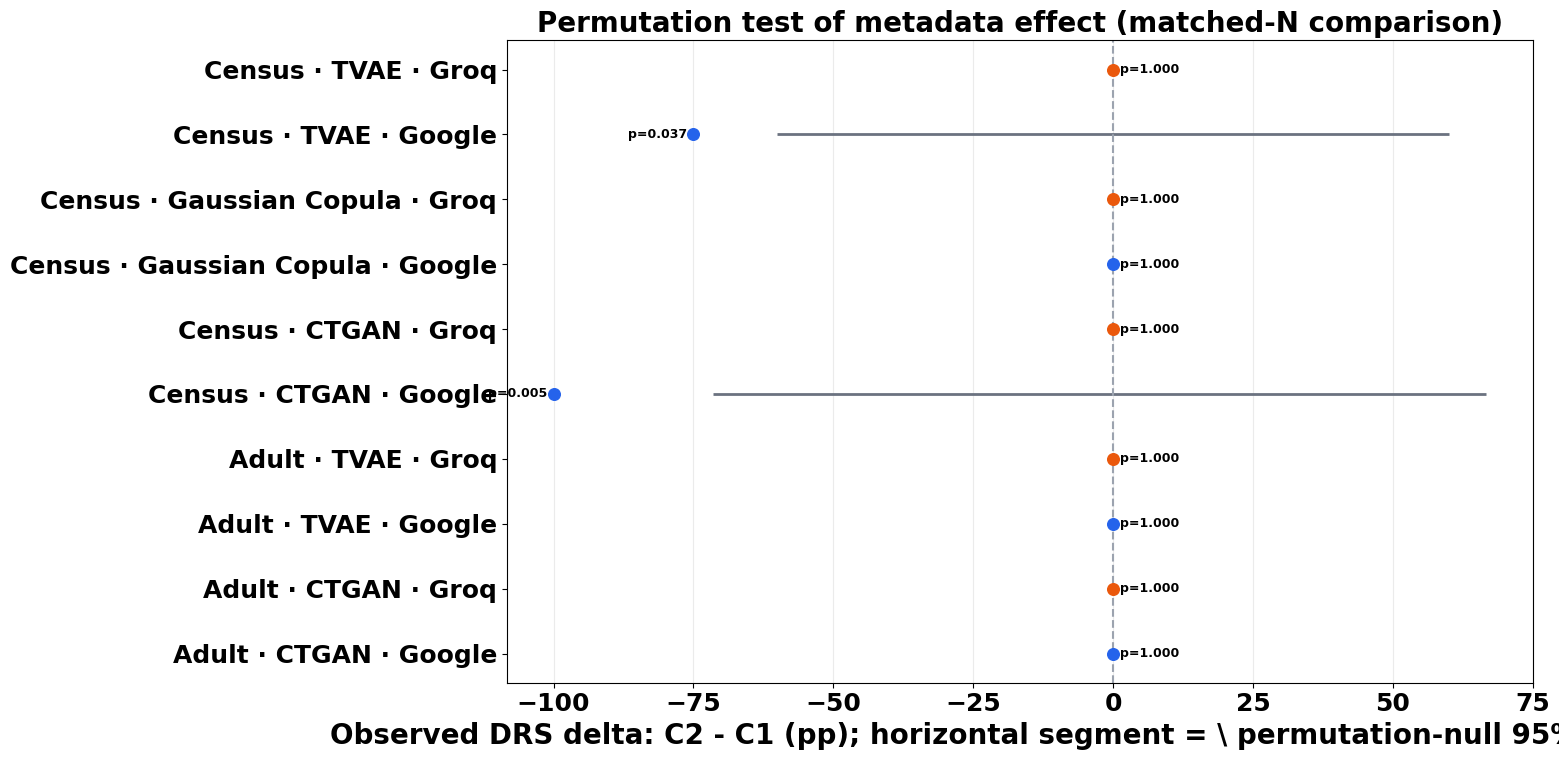

In [8]:
# ── Permutation test: metadata effect (C2 - C1 DRS) per dataset × model × method ──
# Tests whether observed C2->C1 DRS delta is larger than chance under label exchangeability.

PERM_N = 3000
PERM_SEED = 20260531
rng = np.random.default_rng(PERM_SEED)

if 'llm_df_matched' in globals() and LLM_COMPARISON_MODE == 'matched':
    perm_df = llm_df_matched.copy()
    perm_source_name = 'matched-N comparison'
else:
    # Restrict to paired-coverage keys for cross-model comparability in full-N mode.
    perm_df = llm_df.merge(fair_keys, on=['dataset', 'method', 'condition'], how='inner').copy()
    perm_source_name = 'full available comparison'


def drs_from_rows(frame):
    real = frame[frame['true_label'] == 'REAL']
    syn = frame[frame['true_label'] == 'SYNTHETIC']
    p_real = real['correct'].mean() * 100 if len(real) else np.nan
    p_syn = syn['correct'].mean() * 100 if len(syn) else np.nan
    return min(p_real, p_syn) if (not np.isnan(p_real) and not np.isnan(p_syn)) else np.nan


perm_rows = []
for ds in DATASETS:
    for prov_label in list(APPROVED_MODELS.values()):
        for m in METHODS:
            sub = perm_df[
                (perm_df['dataset'] == ds)
                & (perm_df['provider_label'] == prov_label)
                & (perm_df['method'] == m)
                & (perm_df['condition'].isin(['C1', 'C2']))
            ].copy()

            if sub.empty:
                continue

            n_c1 = int((sub['condition'] == 'C1').sum())
            n_c2 = int((sub['condition'] == 'C2').sum())
            if n_c1 == 0 or n_c2 == 0:
                continue

            obs_c1 = drs_from_rows(sub[sub['condition'] == 'C1'])
            obs_c2 = drs_from_rows(sub[sub['condition'] == 'C2'])
            obs_delta = obs_c2 - obs_c1

            cond_arr = sub['condition'].to_numpy()
            perm_deltas = np.empty(PERM_N, dtype=float)
            for bi in range(PERM_N):
                shuffled = cond_arr.copy()
                rng.shuffle(shuffled)
                tmp = sub.copy()
                tmp['perm_condition'] = shuffled

                p_c1 = drs_from_rows(tmp[tmp['perm_condition'] == 'C1'])
                p_c2 = drs_from_rows(tmp[tmp['perm_condition'] == 'C2'])
                perm_deltas[bi] = p_c2 - p_c1

            finite_perm = perm_deltas[np.isfinite(perm_deltas)]
            if len(finite_perm) == 0:
                continue

            p_upper = (np.sum(finite_perm >= obs_delta) + 1) / (len(finite_perm) + 1)
            p_two = (np.sum(np.abs(finite_perm) >= abs(obs_delta)) + 1) / (len(finite_perm) + 1)

            perm_rows.append({
                'dataset': ds,
                'provider_label': prov_label,
                'method': m,
                'N_c1': n_c1,
                'N_c2': n_c2,
                'DRS_C1': obs_c1,
                'DRS_C2': obs_c2,
                'delta_C2_minus_C1': obs_delta,
                'perm_effective_n': int(len(finite_perm)),
                'perm_null_q025': float(np.quantile(finite_perm, 0.025)),
                'perm_null_q975': float(np.quantile(finite_perm, 0.975)),
                'p_one_sided_ge': float(p_upper),
                'p_two_sided': float(p_two),
            })

perm_results = pd.DataFrame(perm_rows).sort_values(['dataset', 'provider_label', 'method']).reset_index(drop=True)
perm_results['method_label'] = perm_results['method'].map(METHOD_LABELS)
perm_results['signif_two_sided_005'] = perm_results['p_two_sided'] < 0.05

print(f'Permutation metadata-effect test complete ({PERM_N} shuffles per cell, source={perm_source_name}).')
display(
    perm_results[
        [
            'dataset', 'provider_label', 'method', 'N_c1', 'N_c2',
            'DRS_C1', 'DRS_C2', 'delta_C2_minus_C1',
            'perm_effective_n', 'perm_null_q025', 'perm_null_q975',
            'p_one_sided_ge', 'p_two_sided', 'signif_two_sided_005'
        ]
    ].round(3)
)

perm_csv = f'{fig_dir}/table_permutation_c1_c2_drs.csv'
perm_results.to_csv(perm_csv, index=False)
print(f'Saved: {perm_csv}')

# Plot observed deltas against permutation null intervals.
plot_perm = perm_results.copy()
plot_perm['cell'] = (
    plot_perm['dataset'].str.capitalize() + ' · '
    + plot_perm['method_label'] + ' · '
    + plot_perm['provider_label'].str.replace(' (LLaMA-3.1-8b)', '', regex=False).str.replace(' (Gemini-2.5-Flash)', '', regex=False)
)
plot_perm = plot_perm.sort_values(['dataset', 'method', 'provider_label']).reset_index(drop=True)

y = np.arange(len(plot_perm))
fig, ax = plt.subplots(figsize=(16, 8))
for i, row in plot_perm.iterrows():
    color = '#2563eb' if 'Google' in row['provider_label'] else '#ea580c'
    x = row['delta_C2_minus_C1']

    # Draw permutation-null interval directly, then overlay observed point.
    ax.hlines(i, row['perm_null_q025'], row['perm_null_q975'], color='#6b7280', lw=2)
    ax.scatter(x, i, s=70, color=color, zorder=3)

    ha = 'left' if x >= 0 else 'right'
    x_text = x + (1.2 if x >= 0 else -1.2)
    ax.text(x_text, i, f"p={row['p_two_sided']:.3f}", va='center', ha=ha, fontsize=9)

ax.axvline(0, ls='--', color='#9ca3af', lw=1.5)
ax.set_yticks(y)
ax.set_yticklabels(plot_perm['cell'])
ax.set_xlabel('Observed DRS delta: C2 - C1 (pp); horizontal segment = \\ permutation-null 95% interval')
ax.set_title(f'Permutation test of metadata effect ({perm_source_name})')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()

path_perm_fig = f'{fig_dir}/fig_permutation_c1_c2_delta.pdf'
plt.savefig(path_perm_fig, bbox_inches='tight')
print(f'Saved: {path_perm_fig}')
plt.show()

In [9]:
# Descriptive model summaries (computed, no hardcoded values)
print('=== Descriptive summary by model (all included cells) ===')
display(model_stats[['provider_label', 'N', 'N_real', 'N_syn', 'Accuracy', 'DRS', 'Pred_REAL_rate', 'Avg_conf']].round(1))

print('=== Descriptive summary by dataset and model ===')
by_dataset_model = grouped_metrics(llm_df, ['dataset', 'provider_label'])
display(by_dataset_model[['dataset', 'provider_label', 'N', 'Accuracy', 'DRS', 'Pred_REAL_rate', 'Avg_conf']].round(1))

print('Note: these are descriptive and can include low-N cells; use fair subset tables for strict comparisons.')

=== Descriptive summary by model (all included cells) ===


,provider_label,N,N_real,N_syn,Accuracy,DRS,Pred_REAL_rate,Avg_conf
0,Google (Gemini-2.5-Flash),104.0,55.0,49.0,92.3,83.7,60.6,95.5
1,Groq (LLaMA-3.1-8b),347.0,174.0,173.0,51.6,20.2,81.3,83.8


=== Descriptive summary by dataset and model ===


,dataset,provider_label,N,Accuracy,DRS,Pred_REAL_rate,Avg_conf
0,adult,Google (Gemini-2.5-Flash),50.0,100.0,100.0,56.0,96.3
1,adult,Groq (LLaMA-3.1-8b),287.0,51.9,3.5,98.3,84.2
2,census,Google (Gemini-2.5-Flash),54.0,85.2,70.4,64.8,94.7
3,census,Groq (LLaMA-3.1-8b),60.0,50.0,0.0,0.0,81.7


Note: these are descriptive and can include low-N cells; use fair subset tables for strict comparisons.


Saved: /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/fig_drs_by_method_condition.pdf


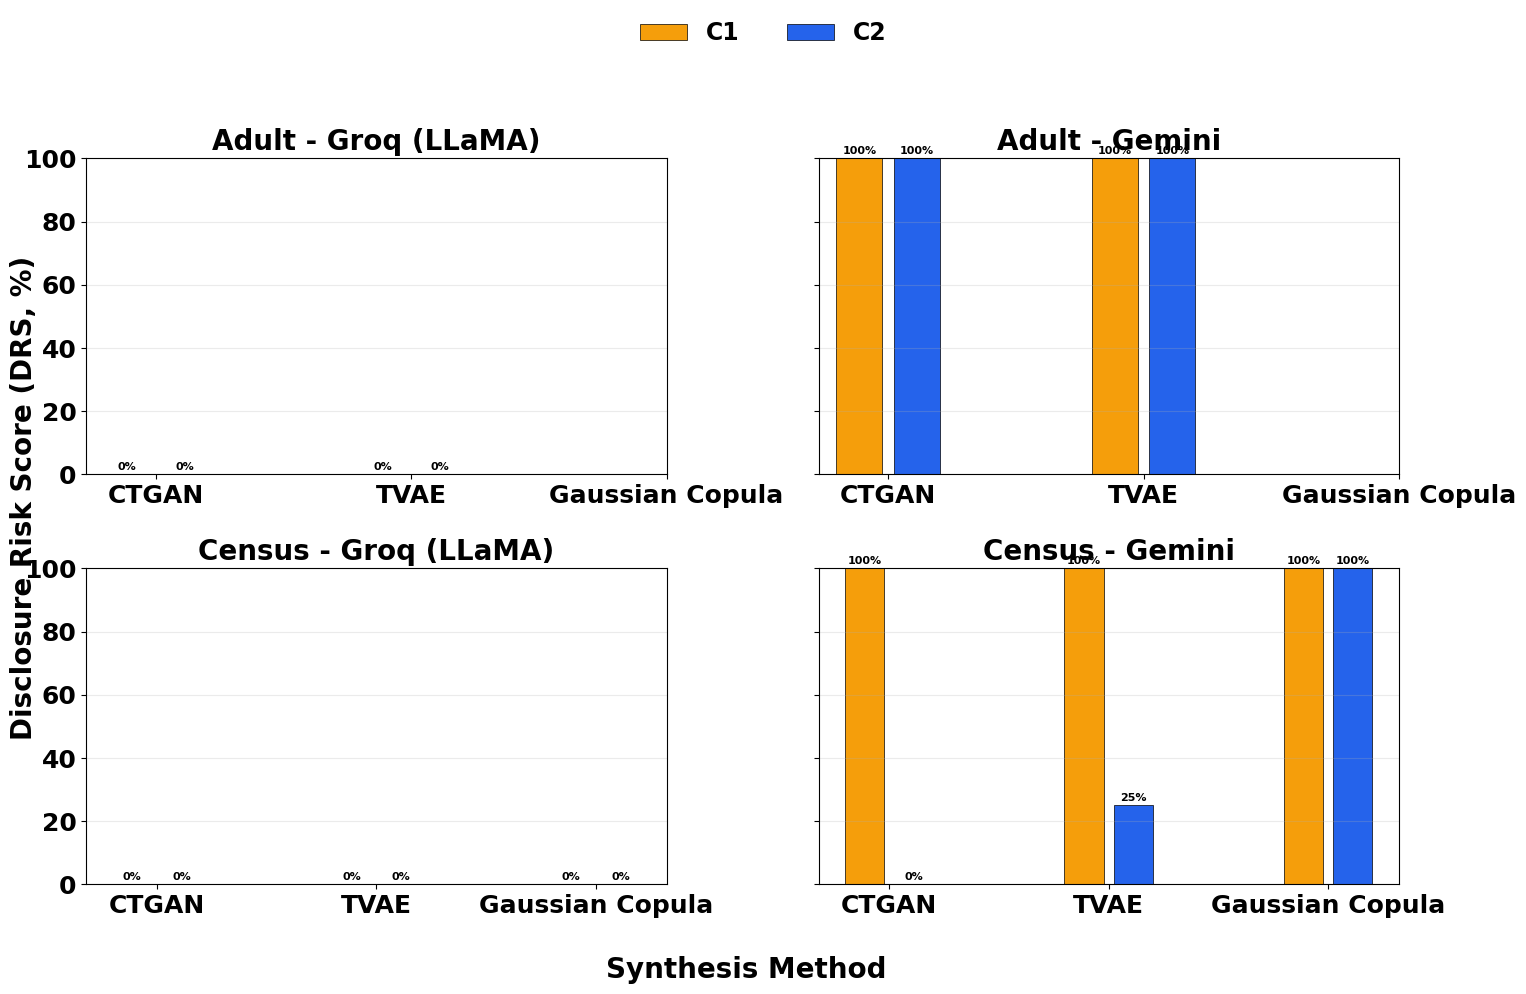

In [10]:
# ── Figure 1: DRS by method x condition, grouped by dataset x model ─────────────
# Comparison figure using the current selection mode (matched or full-available).
# Rows with insufficient paired coverage are omitted by the current data filter.

if 'cell_stats_matched' in globals() and LLM_COMPARISON_MODE == 'matched':
    fig_cell_stats = cell_stats_matched.copy()
    mode_label = 'matched-N comparison'
else:
    fig_cell_stats = cell_stats_fair.copy()
    mode_label = 'full available comparison'

model_display = globals().get('MODEL_DISPLAY', {})
# Local fallback to avoid NameError when colors_cond is not defined upstream.
colors_cond = globals().get('colors_cond', {'C1': '#f59e0b', 'C2': '#2563eb'})

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
bar_w = 0.18

for i, ds in enumerate(DATASETS):
    for j, prov in enumerate(APPROVED_MODELS.values()):
        ax = axes[i, j]
        sub = fig_cell_stats[(fig_cell_stats['dataset'] == ds) & (fig_cell_stats['provider_label'] == prov)]

        x_centers = np.arange(len(METHODS))
        offsets = {'C1': -bar_w/1.6, 'C2': +bar_w/1.6}

        # Draw bars per condition; include explicit 0 labels for zero-height bars.
        for cond, color in zip(CONDS, [colors_cond.get('C1', '#f59e0b'), colors_cond.get('C2', '#2563eb')]):
            vals = [
                float(sub[(sub['method'] == m) & (sub['condition'] == cond)]['DRS'].iloc[0])
                if len(sub[(sub['method'] == m) & (sub['condition'] == cond)]) else np.nan
                for m in METHODS
            ]
            xpos = x_centers + offsets[cond]
            bars = ax.bar(xpos, vals, width=bar_w, color=color, edgecolor='black', linewidth=0.5, label=cond if i==0 and j==0 else None)

            for b, v in zip(bars, vals):
                if np.isnan(v):
                    continue
                y = v + 0.8 if v > 0 else 0.9
                ax.text(b.get_x() + b.get_width()/2, y, f'{v:.0f}%', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x_centers)
        ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=0)
        ax.set_ylim(0, 100)
        display_name = model_display.get(prov, prov.replace(' (LLaMA-3.1-8b)', '').replace(' (Gemini-2.5-Flash)', ''))
        ax.set_title(f'{ds.capitalize()} - {display_name}')
        ax.grid(axis='y', alpha=0.25)

# fig.suptitle(
#     f'LLM DRS ({mode_label})\n'
#     f'Bars omitted when paired coverage is below threshold',
#     fontsize=14,
# )
fig.text(0.04, 0.5, 'Disclosure Risk Score (DRS, %)', va='center', rotation='vertical')
fig.text(0.5, 0.02, 'Synthesis Method', ha='center')
fig.legend(loc='upper center', ncol=2, frameon=False)
plt.tight_layout(rect=[0.03, 0.05, 1, 0.9])

path1 = f'{fig_dir}/fig_drs_by_method_condition.pdf'
plt.savefig(path1, bbox_inches='tight')
print(f'Saved: {path1}')
plt.show()

Saved: /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/fig_drs_decomposition.pdf


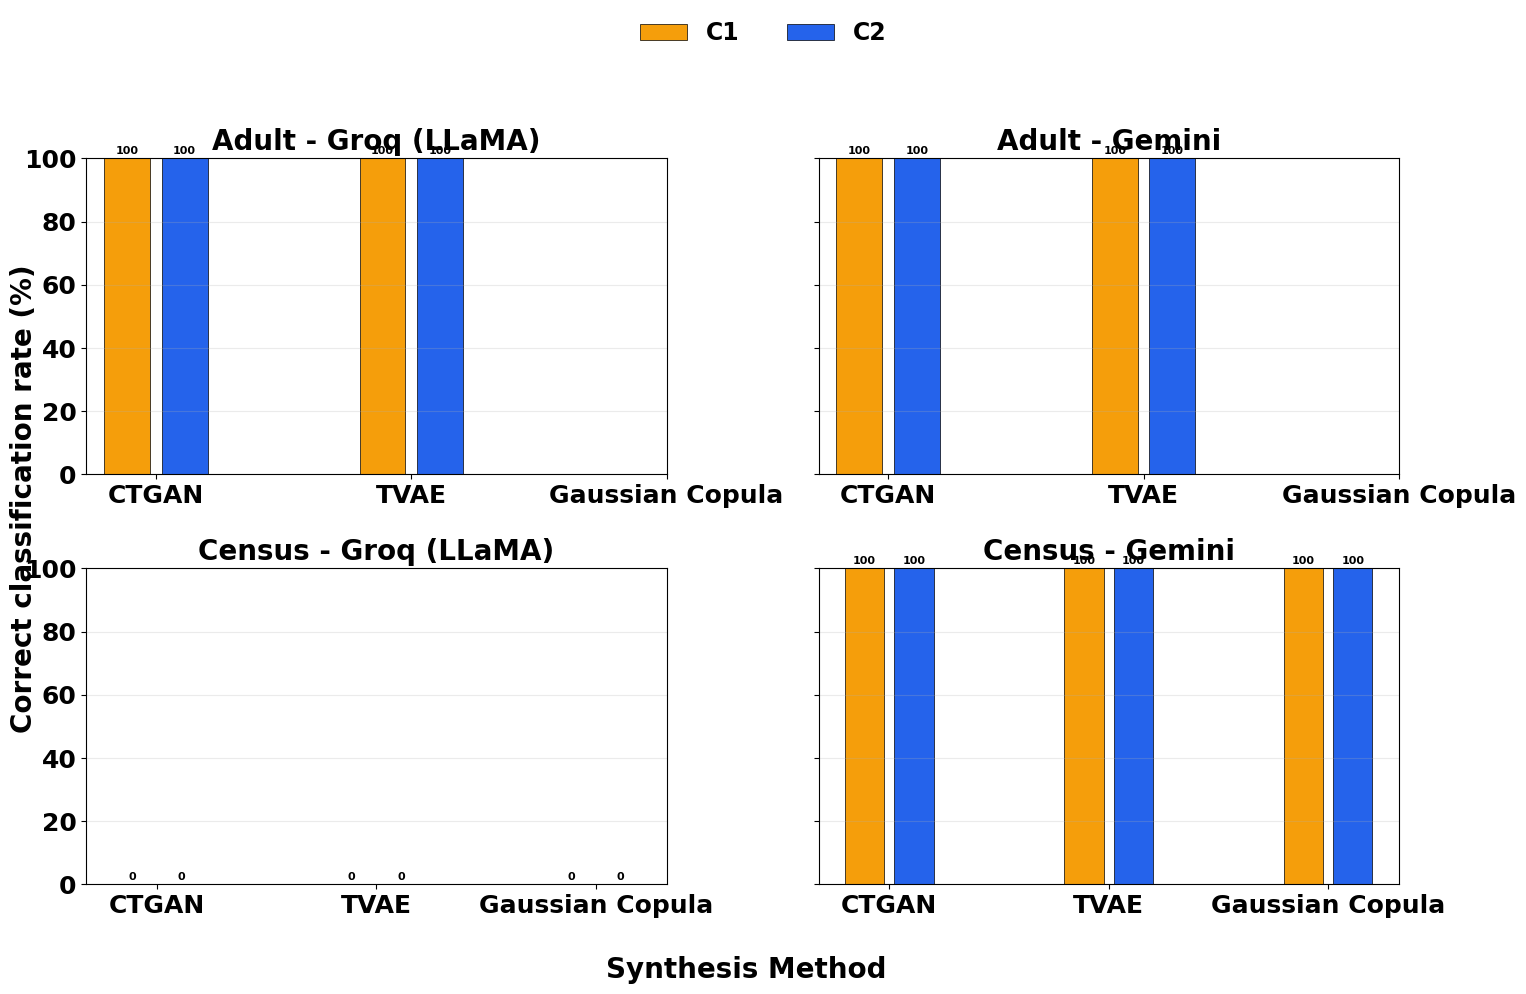

In [11]:
# ── Figure 1b: DRS decomposition per method x condition ─────────────────────────

if 'cell_stats_matched' in globals() and LLM_COMPARISON_MODE == 'matched':
    fig_cell_stats_decomp = cell_stats_matched.copy()
    decomp_mode_label = 'matched-N comparison'
else:
    fig_cell_stats_decomp = cell_stats_fair.copy()
    decomp_mode_label = 'full available comparison'

model_display = globals().get('MODEL_DISPLAY', {})

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
bar_w = 0.18

for i, ds in enumerate(DATASETS):
    for j, prov in enumerate(APPROVED_MODELS.values()):
        ax = axes[i, j]
        sub = fig_cell_stats_decomp[(fig_cell_stats_decomp['dataset'] == ds) & (fig_cell_stats_decomp['provider_label'] == prov)]

        x_centers = np.arange(len(METHODS))
        offsets = {'C1': -bar_w/1.6, 'C2': +bar_w/1.6}

        for cond, color in zip(CONDS, [colors_cond['C1'], colors_cond['C2']]):
            vals = [
                float(sub[(sub['method'] == m) & (sub['condition'] == cond)]['p_real_correct'].iloc[0])
                if len(sub[(sub['method'] == m) & (sub['condition'] == cond)]) else np.nan
                for m in METHODS
            ]
            xpos = x_centers + offsets[cond]
            bars = ax.bar(xpos, vals, width=bar_w, color=color, edgecolor='black', linewidth=0.5, label=cond if i==0 and j==0 else None)
            for b, v in zip(bars, vals):
                if np.isnan(v):
                    continue
                y = v + 0.8 if v > 0 else 0.9
                ax.text(b.get_x() + b.get_width()/2, y, f'{v:.0f}', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x_centers)
        ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=0)
        ax.set_ylim(0, 100)
        display_name = model_display.get(prov, prov.replace(' (LLaMA-3.1-8b)', '').replace(' (Gemini-2.5-Flash)', ''))
        ax.set_title(f'{ds.capitalize()} - {display_name}')
        ax.grid(axis='y', alpha=0.25)

# fig.suptitle(
#     f'DRS decomposition ({decomp_mode_label}): p_real, p_syn',
#     fontsize=14,
# )
fig.text(0.04, 0.5, 'Correct classification rate (%)', va='center', rotation='vertical')
fig.text(0.5, 0.02, 'Synthesis Method', ha='center')
fig.legend(loc='upper center', ncol=2, frameon=False)
plt.tight_layout(rect=[0.03, 0.05, 1, 0.9])

path1b = f'{fig_dir}/fig_drs_decomposition.pdf'
plt.savefig(path1b, bbox_inches='tight')
print(f'Saved: {path1b}')
plt.show()

Saved: /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/fig_model_bias_confidence.pdf


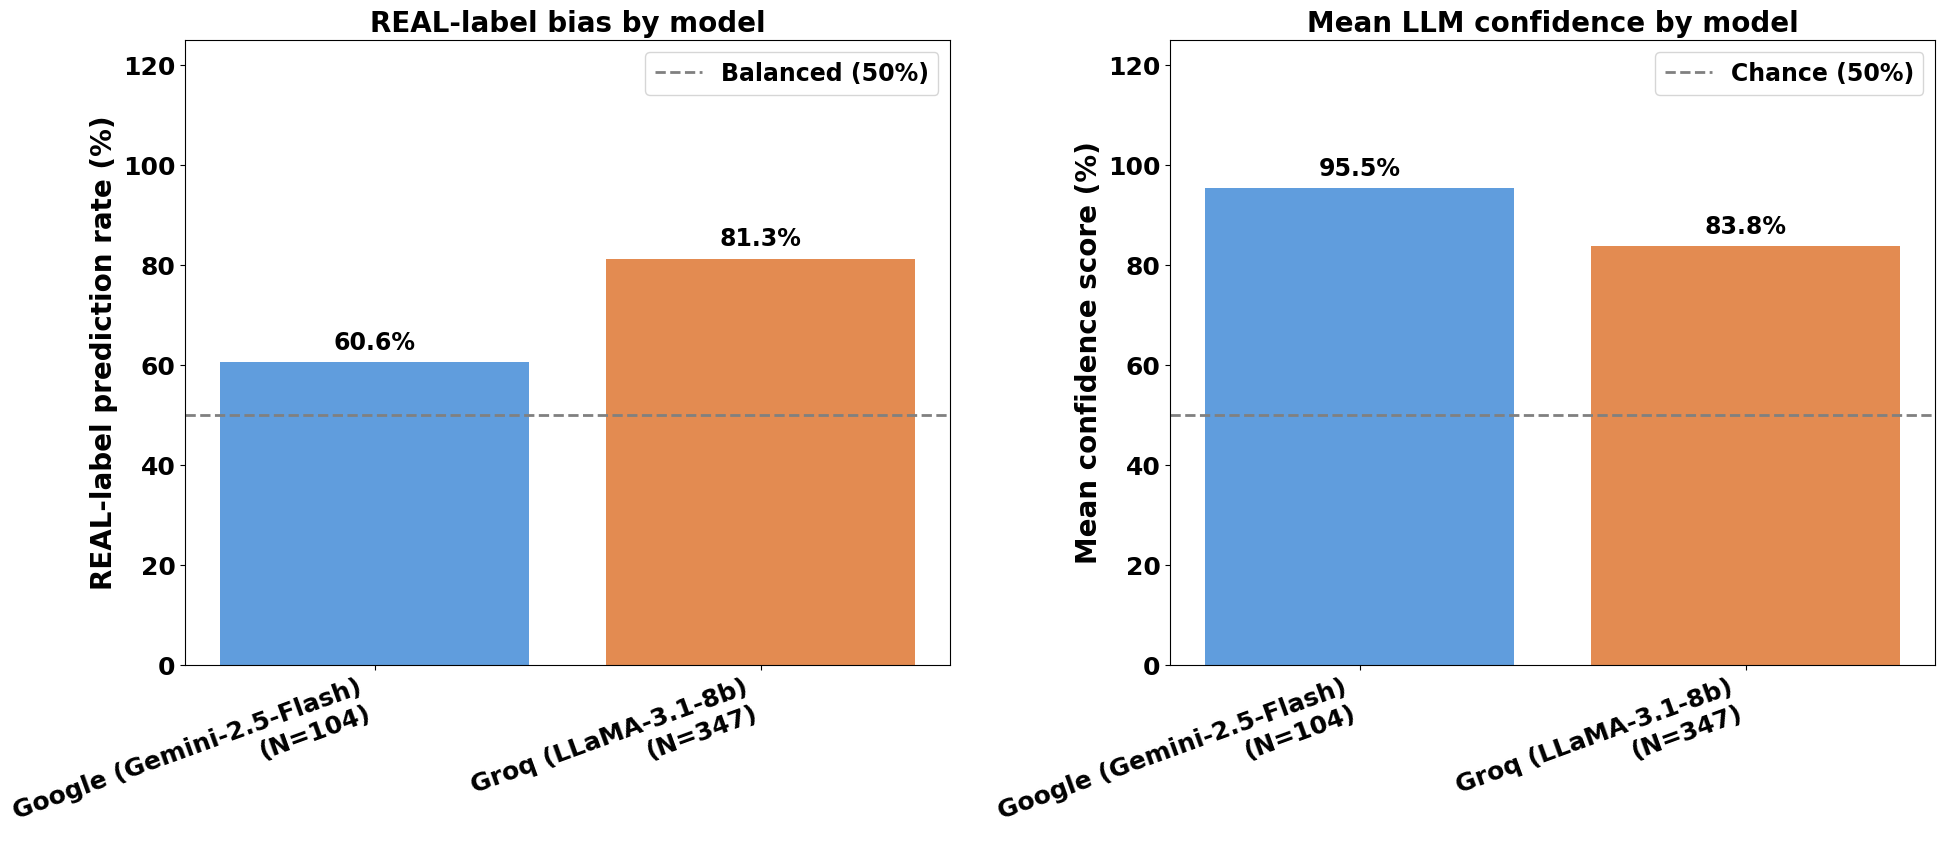

In [12]:
# ── Figure 2: REAL-label bias and mean confidence by model (computed) ─────────
model_plot = model_stats.copy().sort_values('provider_label')
names = [f"{r['provider_label']}\n(N={int(r['N'])})" for _, r in model_plot.iterrows()]
pred_real = model_plot['Pred_REAL_rate'].to_list()
conf = model_plot['Avg_conf'].to_list()
bar_colors = ['#4a90d9', '#e07b39'][:len(names)]

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

axes[0].bar(names, pred_real, color=bar_colors, alpha=0.88)
axes[0].axhline(50, ls='--', color='grey', lw=2.0, label='Balanced (50%)')
axes[0].set_ylabel('REAL-label prediction rate (%)')
axes[0].set_title('REAL-label bias by model')
axes[0].set_ylim(0, 125)
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')
for i, v in enumerate(pred_real):
    axes[0].text(i, v + 1.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=17, fontweight='bold')

axes[1].bar(names, conf, color=bar_colors, alpha=0.88)
axes[1].axhline(50, ls='--', color='grey', lw=2.0, label='Chance (50%)')
axes[1].set_ylabel('Mean confidence score (%)')
axes[1].set_title('Mean LLM confidence by model')
axes[1].set_ylim(0, 125)
axes[1].legend()
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')
for i, v in enumerate(conf):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=17, fontweight='bold')

plt.tight_layout()
path2 = f'{fig_dir}/fig_model_bias_confidence.pdf'
plt.savefig(path2, bbox_inches='tight')
print(f'Saved: {path2}')
plt.show()

## 2. Human annotation results

**2 annotators**: HA1 and HA2, collected 30 May 2026.  
**Design**: paired C1 → C2 (same 20-row sample shown first without metadata, then with full distributional metadata); 10 pairs per session; 6 sessions each (2 datasets × 3 methods).  
**Total**: ~240 raw rows → deduplicated to 120 unique trials per annotator.

> **DRS** = min(p_real, p_syn)  where  p_real = P(predict REAL | true REAL),  p_syn = P(predict SYN | true SYN)

In [16]:
# ── Load & deduplicate all human annotation CSVs ─────────────────────────────
HUMAN_DIR = ROOT / 'results' / 'human'

dfs = []
for f in sorted(HUMAN_DIR.rglob('human_results_*.csv')):
    df = pd.read_csv(f)
    df['source_file'] = f.name
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
deduped = all_df.drop_duplicates(subset=['session_id', 'dataset', 'method', 'pair_id', 'condition']).copy()

# Display aliases for anonymized reporting
raw_annotators = sorted(deduped['annotator_id'].astype(str).unique())
id_to_ha = {aid: f'HA{i+1}' for i, aid in enumerate(raw_annotators)}
deduped['annotator'] = deduped['annotator_id'].astype(str).map(id_to_ha)
annotators = sorted(deduped['annotator'].unique())

print(f'Raw rows : {len(all_df)}')
print(f'Deduped  : {len(deduped)}  (removed {len(all_df) - len(deduped)} duplicate rows)')
print(f'Annotators (anonymized): {annotators}')
print()
print('Sessions per annotator × dataset × method:')
print(deduped.groupby(['annotator', 'dataset', 'method'])['session_id'].nunique().to_string())

# ── DRS helper ────────────────────────────────────────────────────────────────
def compute_drs(df):
    real = df[df['true_label'] == 'REAL']
    syn = df[df['true_label'] == 'SYNTHETIC']
    p_r = real['correct'].mean() * 100 if len(real) > 0 else np.nan
    p_s = syn['correct'].mean() * 100 if len(syn) > 0 else np.nan
    drs = min(p_r, p_s) if (not np.isnan(p_r) and not np.isnan(p_s)) else np.nan
    return {
        'N': len(df), 'N_real': len(real), 'N_syn': len(syn),
        'p_real': round(p_r, 1), 'p_syn': round(p_s, 1),
        'DRS': round(drs, 1) if not np.isnan(drs) else np.nan,
        'acc': round(df['correct'].mean() * 100, 1),
        'conf': round(df['confidence'].mean(), 1)
    }

# ── Per-annotator DRS ─────────────────────────────────────────────────────────
rows_ann = []
for ann in annotators:
    ann_df = deduped[deduped['annotator'] == ann]
    for ds in DATASETS:
        for meth in METHODS:
            for cond in CONDS:
                sub = ann_df[(ann_df['dataset'] == ds) & (ann_df['method'] == meth) & (ann_df['condition'] == cond)]
                if len(sub) == 0:
                    continue
                r = compute_drs(sub)
                r.update({'annotator': ann, 'dataset': ds, 'method': meth, 'condition': cond})
                rows_ann.append(r)

per_ann = pd.DataFrame(rows_ann)[['annotator', 'dataset', 'method', 'condition', 'N', 'p_real', 'p_syn', 'DRS', 'acc', 'conf']]
print('\n── Per-annotator DRS ────────────────────────────────────────────────────')
display(per_ann.round(1))

# ── LLM reference source selection (matched if available) ─────────────────────
if 'cell_stats_matched' in globals() and LLM_COMPARISON_MODE == 'matched':
    llm_source = cell_stats_matched.copy()
    llm_source_name = 'matched-N'
else:
    llm_source = cell_stats_fair.copy()
    llm_source_name = 'fair-full-N'

llm_lookup = {}
for _, row in llm_source.iterrows():
    key = (row['dataset'], row['method'], row['condition'], row['provider_label'])
    llm_lookup[key] = {'DRS': row['DRS'], 'N': int(row['N'])}

groq_label = 'Groq (LLaMA-3.1-8b)'
gemini_label = 'Google (Gemini-2.5-Flash)'

# ── Pooled human DRS + per-annotator columns + fair LLM columns ──────────────
rows_pool = []
for ds in DATASETS:
    for meth in METHODS:
        for cond in CONDS:
            sub = deduped[(deduped['dataset'] == ds) & (deduped['method'] == meth) & (deduped['condition'] == cond)]
            if len(sub) == 0:
                continue

            r = compute_drs(sub)
            r.update({'dataset': ds, 'method': meth, 'condition': cond})

            for ann in annotators:
                ann_sub = sub[sub['annotator'] == ann]
                r[f'DRS_{ann}'] = compute_drs(ann_sub)['DRS'] if len(ann_sub) > 0 else np.nan

            g = llm_lookup.get((ds, meth, cond, groq_label), {'DRS': np.nan, 'N': 0})
            gm = llm_lookup.get((ds, meth, cond, gemini_label), {'DRS': np.nan, 'N': 0})
            r['Groq_N'] = g['N']
            r['Gemini_N'] = gm['N']

            # Keep fair gating (already enforced by source), and preserve explicit flag.
            fair_cell = min(g['N'], gm['N']) >= FAIR_MIN_N
            r['Groq_DRS'] = g['DRS'] if fair_cell else np.nan
            r['Gemini_DRS'] = gm['DRS'] if fair_cell else np.nan
            r['fair_cell'] = fair_cell
            rows_pool.append(r)

summary = pd.DataFrame(rows_pool)

# Inter-rater consistency: absolute difference in DRS between annotators per cell
drs_cols = [f'DRS_{a}' for a in annotators]
if len(drs_cols) == 2:
    summary['DRS_diff'] = (summary[drs_cols[0]] - summary[drs_cols[1]]).abs()
    mean_diff = summary['DRS_diff'].mean()
    print(f'\nMean |{drs_cols[0]} - {drs_cols[1]}| across all cells: {mean_diff:.1f} pp')

print(f"\nLLM source for this table: {llm_source_name}")
print(f'Fair cells used for LLM comparison in this table: {int(summary["fair_cell"].sum())}/{len(summary)}')
print('\n── Pooled DRS vs LLM DRS (fair cells only for LLM columns) ─────────────────')
show_cols = ['dataset', 'method', 'condition', 'DRS'] + drs_cols + ['Groq_N', 'Gemini_N', 'fair_cell', 'Groq_DRS', 'Gemini_DRS']
display(summary[[c for c in show_cols if c in summary.columns]].round(1))

Raw rows : 260
Deduped  : 240  (removed 20 duplicate rows)
Annotators (anonymized): ['HA1', 'HA2']

Sessions per annotator × dataset × method:
annotator  dataset  method         
HA1        adult    ctgan              1
                    gaussian_copula    1
                    tvae               1
           census   ctgan              1
                    gaussian_copula    1
                    tvae               1
HA2        adult    ctgan              1
                    gaussian_copula    1
                    tvae               1
           census   ctgan              1
                    gaussian_copula    1
                    tvae               1

── Per-annotator DRS ────────────────────────────────────────────────────


,annotator,dataset,method,condition,N,p_real,p_syn,DRS,acc,conf
0,HA1,adult,ctgan,C1,10,50.0,66.7,50.0,60.0,63.5
1,HA1,adult,ctgan,C2,10,50.0,33.3,33.3,40.0,63.4
2,HA1,adult,tvae,C1,10,50.0,83.3,50.0,70.0,61.2
3,HA1,adult,tvae,C2,10,25.0,100.0,25.0,70.0,65.1
4,HA1,adult,gaussian_copula,C1,10,80.0,100.0,80.0,90.0,74.3
5,HA1,adult,gaussian_copula,C2,10,80.0,100.0,80.0,90.0,72.3
6,HA1,census,ctgan,C1,10,40.0,60.0,40.0,50.0,50.0
7,HA1,census,ctgan,C2,10,40.0,40.0,40.0,40.0,50.0
8,HA1,census,tvae,C1,10,33.3,50.0,33.3,40.0,50.0
9,HA1,census,tvae,C2,10,33.3,25.0,25.0,30.0,50.0



Mean |DRS_HA1 - DRS_HA2| across all cells: 20.6 pp

LLM source for this table: matched-N
Fair cells used for LLM comparison in this table: 10/12

── Pooled DRS vs LLM DRS (fair cells only for LLM columns) ─────────────────


,dataset,method,condition,DRS,DRS_HA1,DRS_HA2,Groq_N,Gemini_N,fair_cell,Groq_DRS,Gemini_DRS
0,adult,ctgan,C1,63.6,50.0,60.0,12,12,True,0.0,100.0
1,adult,ctgan,C2,63.6,33.3,100.0,12,12,True,0.0,100.0
2,adult,tvae,C1,75.0,50.0,50.0,11,11,True,0.0,100.0
3,adult,tvae,C2,66.7,25.0,50.0,11,11,True,0.0,100.0
4,adult,gaussian_copula,C1,75.0,80.0,66.7,0,0,False,NaN,NaN
5,adult,gaussian_copula,C2,87.5,80.0,100.0,0,0,False,NaN,NaN
6,census,ctgan,C1,54.5,40.0,66.7,9,9,True,0.0,100.0
7,census,ctgan,C2,66.7,40.0,100.0,10,10,True,0.0,0.0
8,census,tvae,C1,33.3,33.3,33.3,9,9,True,0.0,100.0
9,census,tvae,C2,37.5,25.0,50.0,9,9,True,0.0,25.0


Spearman agreement summary:


,scope,rho,p_value,N
0,overall,-0.0182,0.9394,20
1,Gemini,0.0827,0.8204,10
2,Groq,NaN,NaN,10


Bland-Altman overall: mean diff=-19.84, LoA=[-121.12, 81.44] pp
Saved: /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/fig_human_llm_agreement_bland_altman.pdf


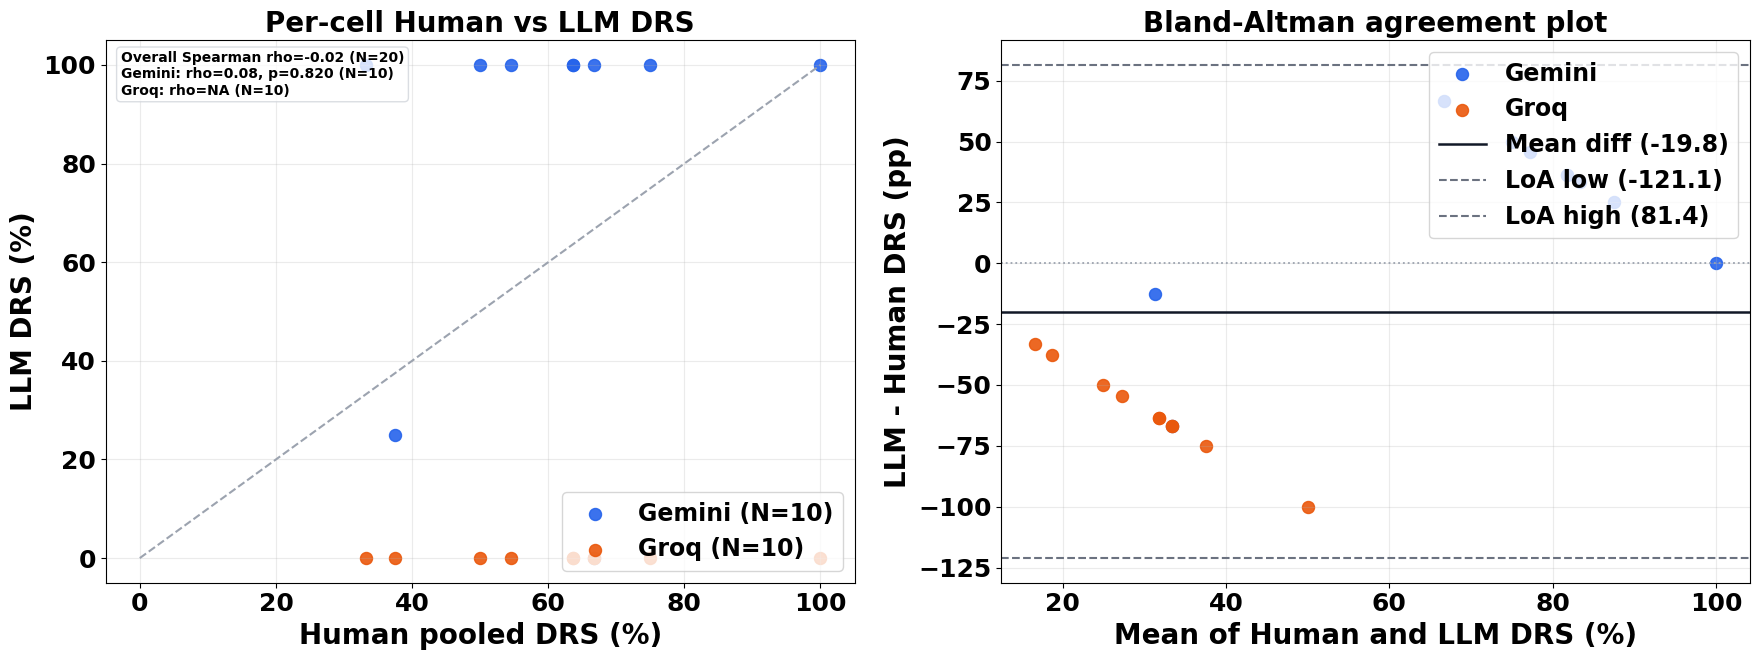

In [15]:
# ── Human↔LLM agreement analysis: Spearman + Bland-Altman ─────────────────────

model_col_map = [('Groq', 'Groq_DRS'), ('Gemini', 'Gemini_DRS')]
required_base_cols = ['dataset', 'method', 'condition', 'DRS']

if 'summary' not in globals() or summary is None or summary.empty:
    print('Skipping agreement analysis: summary is missing. Run the human summary cell first.')
else:
    missing_base = [c for c in required_base_cols if c not in summary.columns]
    missing_model = [c for _, c in model_col_map if c not in summary.columns]
    if missing_base or missing_model:
        print('Skipping agreement analysis due to missing columns in summary:')
        print('  Missing base columns :', missing_base)
        print('  Missing model columns:', missing_model)
    else:
        agree_parts = []
        for model_name, col in model_col_map:
            part = summary[['dataset', 'method', 'condition', 'DRS', col]].copy()
            part = part.rename(columns={'DRS': 'human_drs', col: 'llm_drs'})
            part['model'] = model_name
            part = part[part['llm_drs'].notna()].copy()
            agree_parts.append(part)

        agreement_df = pd.concat(agree_parts, ignore_index=True)
        agreement_df['cell'] = (
            agreement_df['dataset'].str.capitalize() + ' · '
            + agreement_df['method'].map(METHOD_LABELS).fillna(agreement_df['method']) + ' · '
            + agreement_df['condition']
        )

        if agreement_df.empty:
            print('Skipping agreement analysis: no overlapping Human/LLM DRS values found.')
        else:
            def safe_spearman(x, y):
                pair = pd.DataFrame({'x': x, 'y': y}).dropna()
                n = len(pair)
                if n < 2:
                    return np.nan, np.nan, n

                # Spearman is undefined when one variable is constant.
                if pair['x'].nunique() < 2 or pair['y'].nunique() < 2:
                    return np.nan, np.nan, n

                try:
                    from scipy.stats import spearmanr

                    rho, p = spearmanr(pair['x'], pair['y'])
                    return float(rho), float(p), n
                except Exception:
                    rho = pair['x'].corr(pair['y'], method='spearman')
                    return float(rho), np.nan, n

            rho_all, p_all, n_all = safe_spearman(agreement_df['human_drs'], agreement_df['llm_drs'])
            corr_rows = [{'scope': 'overall', 'rho': rho_all, 'p_value': p_all, 'N': int(n_all)}]

            for model_name, g in agreement_df.groupby('model'):
                rho, p, n = safe_spearman(g['human_drs'], g['llm_drs'])
                corr_rows.append({'scope': model_name, 'rho': rho, 'p_value': p, 'N': int(n)})

            agreement_corr = pd.DataFrame(corr_rows)
            print('Spearman agreement summary:')
            display(agreement_corr.round(4))

            # Bland-Altman quantities
            agreement_df['mean_human_llm'] = (agreement_df['human_drs'] + agreement_df['llm_drs']) / 2.0
            agreement_df['diff_llm_minus_human'] = agreement_df['llm_drs'] - agreement_df['human_drs']

            diff_valid = agreement_df['diff_llm_minus_human'].dropna()
            mean_diff = float(diff_valid.mean()) if len(diff_valid) else np.nan
            sd_diff = float(diff_valid.std(ddof=1)) if len(diff_valid) >= 2 else np.nan
            loa_low = mean_diff - 1.96 * sd_diff if np.isfinite(sd_diff) else np.nan
            loa_high = mean_diff + 1.96 * sd_diff if np.isfinite(sd_diff) else np.nan

            if np.isfinite(loa_low) and np.isfinite(loa_high):
                print(f"Bland-Altman overall: mean diff={mean_diff:.2f}, LoA=[{loa_low:.2f}, {loa_high:.2f}] pp")
            else:
                print(f"Bland-Altman overall: mean diff={mean_diff:.2f}, LoA=NA (insufficient variance or sample size)")

            # Two-panel agreement figure
            fig, axes = plt.subplots(1, 2, figsize=(18, 7))
            colors = {'Groq': '#ea580c', 'Gemini': '#2563eb'}

            # Panel A: Human vs LLM scatter
            ax = axes[0]
            for model_name, g in agreement_df.groupby('model'):
                ax.scatter(
                    g['human_drs'],
                    g['llm_drs'],
                    s=75,
                    alpha=0.9,
                    color=colors.get(model_name, '#374151'),
                    label=f"{model_name} (N={len(g)})"
                )

            finite_h = agreement_df['human_drs'].dropna()
            finite_l = agreement_df['llm_drs'].dropna()
            if len(finite_h) and len(finite_l):
                min_xy = float(np.nanmin([finite_h.min(), finite_l.min()]))
                max_xy = float(np.nanmax([finite_h.max(), finite_l.max()]))
                if np.isfinite(min_xy) and np.isfinite(max_xy) and min_xy != max_xy:
                    ax.plot([min_xy, max_xy], [min_xy, max_xy], ls='--', color='#9ca3af', lw=1.5)

            ax.set_xlabel('Human pooled DRS (%)')
            ax.set_ylabel('LLM DRS (%)')
            ax.set_title('Per-cell Human vs LLM DRS')
            ax.grid(alpha=0.25)
            ax.legend(loc='lower right')

            corr_lines = []
            for r in agreement_corr.itertuples(index=False):
                if r.scope == 'overall':
                    if np.isfinite(r.rho):
                        corr_lines.append(f"Overall Spearman rho={r.rho:.2f} (N={int(r.N)})")
                    else:
                        corr_lines.append(f"Overall Spearman rho=NA (N={int(r.N)})")
                else:
                    if np.isfinite(r.rho) and np.isfinite(r.p_value):
                        corr_lines.append(f"{r.scope}: rho={r.rho:.2f}, p={r.p_value:.3f} (N={int(r.N)})")
                    elif np.isfinite(r.rho):
                        corr_lines.append(f"{r.scope}: rho={r.rho:.2f} (N={int(r.N)})")
                    else:
                        corr_lines.append(f"{r.scope}: rho=NA (N={int(r.N)})")

            corr_text = '\n'.join(corr_lines)
            ax.text(
                0.02,
                0.98,
                corr_text,
                transform=ax.transAxes,
                va='top',
                ha='left',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='#d1d5db')
            )

            # Panel B: Bland-Altman
            ax = axes[1]
            for model_name, g in agreement_df.groupby('model'):
                ax.scatter(
                    g['mean_human_llm'],
                    g['diff_llm_minus_human'],
                    s=75,
                    alpha=0.9,
                    color=colors.get(model_name, '#374151'),
                    label=model_name
                )

            if np.isfinite(mean_diff):
                ax.axhline(mean_diff, color='#111827', lw=1.8, label=f'Mean diff ({mean_diff:.1f})')
            if np.isfinite(loa_low):
                ax.axhline(loa_low, color='#6b7280', ls='--', lw=1.5, label=f'LoA low ({loa_low:.1f})')
            if np.isfinite(loa_high):
                ax.axhline(loa_high, color='#6b7280', ls='--', lw=1.5, label=f'LoA high ({loa_high:.1f})')

            ax.axhline(0, color='#9ca3af', ls=':', lw=1.3)
            ax.set_xlabel('Mean of Human and LLM DRS (%)')
            ax.set_ylabel('LLM - Human DRS (pp)')
            ax.set_title('Bland-Altman agreement plot')
            ax.grid(alpha=0.25)
            ax.legend(loc='upper right')

            plt.tight_layout()
            path_agree = f'{fig_dir}/fig_human_llm_agreement_bland_altman.pdf'
            plt.savefig(path_agree, bbox_inches='tight')
            print(f'Saved: {path_agree}')
            plt.show()

Saved: /Users/mslokom/Documents/research_directions/data-synthesis-sprite/PSD2026/results/fig_human_vs_llm_drs.pdf


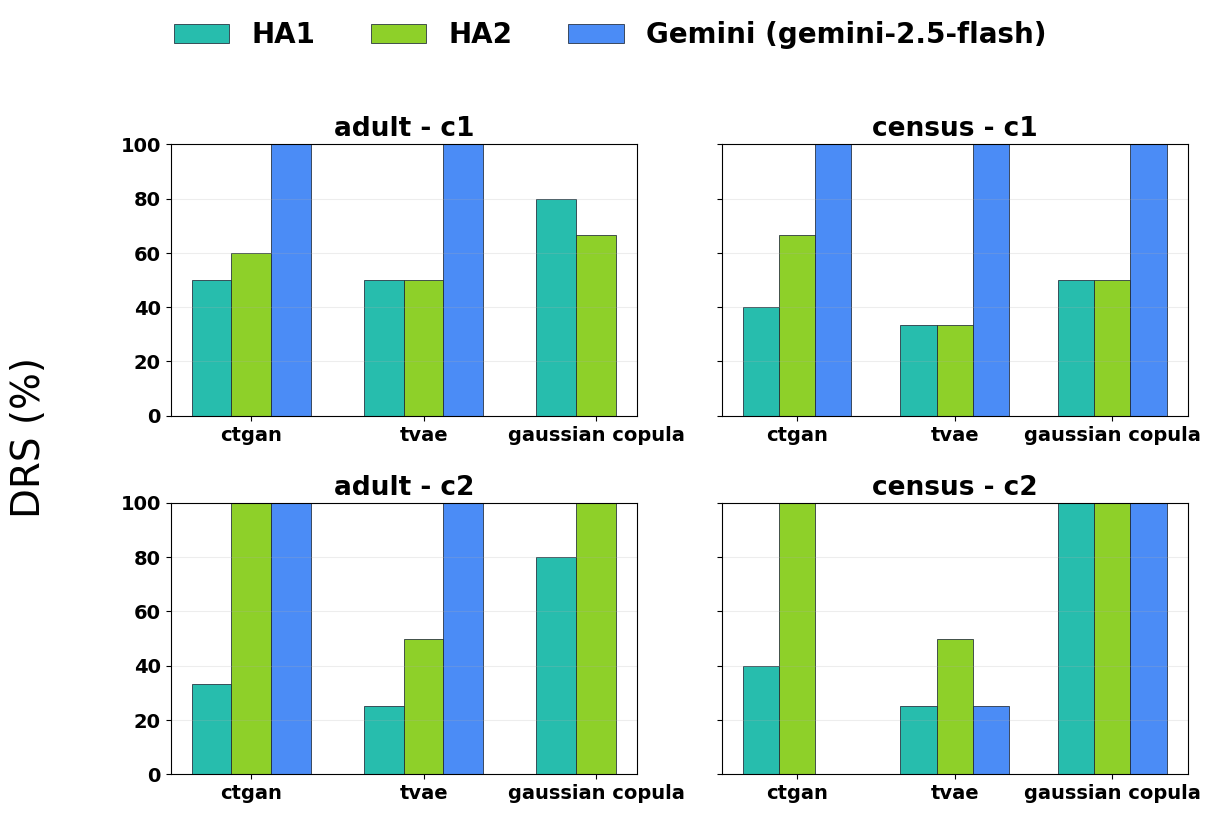

In [23]:
# ── Figure 3: Human vs Gemini DRS (condition-split, compact layout) ───────────
# Keep only HA1, HA2, and Gemini. No pooled human, no Groq.

required_cols = ['dataset', 'method', 'condition', 'Gemini_DRS']
missing = [c for c in required_cols if c not in summary.columns]
if missing:
    print('Skipping figure: summary is missing required columns:', missing)
else:
    # Resolve anonymized annotator columns (expects HA1/HA2 naming from upstream cell).
    ha_cols = [c for c in summary.columns if c.startswith('DRS_HA')]
    ha_labels = [c.replace('DRS_', '') for c in ha_cols]

    # Keep only HA1 and HA2 if present, then add Gemini.
    keep_pairs = [(lbl, col) for lbl, col in zip(ha_labels, ha_cols) if lbl in {'HA1', 'HA2'}]
    if not keep_pairs:
        keep_pairs = list(zip(ha_labels[:2], ha_cols[:2]))

    series_defs = []
    human_colors = {
        'HA1': '#14b8a6',   # teal
        'HA2': '#84cc16',   # lime
    }
    for lbl, col in keep_pairs:
        series_defs.append((lbl, col, human_colors.get(lbl, '#10b981')))

    series_defs.append(('Gemini (gemini-2.5-flash)', 'Gemini_DRS', '#3b82f6'))

    n_rows = len(CONDS)
    n_cols = len(DATASETS)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12.5, 9.0),
        sharey=True,
    )

    # Normalize axes indexing for 1-row/1-col edge cases.
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array([[ax] for ax in axes])

    x_centers = np.arange(len(METHODS))
    bar_w = 0.23
    offsets = np.linspace(-bar_w, bar_w, len(series_defs))

    # Lowercase method labels by request.
    method_labels_plot = [METHOD_LABELS[m].lower() for m in METHODS]

    for ri, cond in enumerate(CONDS):
        for ci, ds in enumerate(DATASETS):
            ax = axes[ri, ci]
            sub = summary[(summary['dataset'] == ds) & (summary['condition'] == cond)]

            for si, (label, col, color) in enumerate(series_defs):
                vals = []
                for m in METHODS:
                    row = sub[sub['method'] == m]
                    vals.append(float(row[col].iloc[0]) if len(row) and pd.notna(row[col].iloc[0]) else np.nan)

                ax.bar(
                    x_centers + offsets[si],
                    vals,
                    width=bar_w,
                    color=color,
                    edgecolor='#1f2937',
                    linewidth=0.6,
                    alpha=0.92,
                    label=label if (ri == 0 and ci == 0) else None,
                )

            ax.set_xticks(x_centers)
            ax.set_xticklabels(method_labels_plot, fontsize=14)
            ax.set_ylim(0, 100)
            ax.grid(axis='y', alpha=0.22)
            ax.set_title(f"{ds} - {cond.lower()}", fontsize=19)
            ax.tick_params(axis='y', labelsize=14)

    fig.supylabel('DRS (%)', fontsize=28)
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=3, frameon=False, fontsize=20)

    plt.tight_layout(rect=[0.03, 0.06, 1, 0.89])

    path3 = f'{fig_dir}/fig_human_vs_llm_drs.pdf'
    plt.savefig(path3, bbox_inches='tight')
    print(f'Saved: {path3}')
    plt.show()

In [16]:
# ── Per-annotator notes, C1→C2 delta, and confidence calibration ─────────────
for ann in annotators:
    ann_df = deduped[deduped["annotator"] == ann].copy()
    print(f"═══ Annotator: {ann}  (N={len(ann_df)}) ════════════════════════════════════")

    # Qualitative notes
    notes = ann_df["notes"].dropna()
    notes = notes[notes.str.strip() != ""]
    if len(notes):
        print(f"\n  Free-text notes ({len(notes)} entries):")
        for i, n in enumerate(notes.values[:10], 1):
            print(f"    [{i}] {n}")
    else:
        print("  (no notes recorded)")

    # C1 → C2 delta
    print(f"\n  Condition DRS delta (C2 − C1) per dataset × method:")
    for ds in DATASETS:
        for meth in METHODS:
            c1 = ann_df[(ann_df["dataset"] == ds) & (ann_df["method"] == meth) & (ann_df["condition"] == "C1")]
            c2 = ann_df[(ann_df["dataset"] == ds) & (ann_df["method"] == meth) & (ann_df["condition"] == "C2")]
            if len(c1) == 0 or len(c2) == 0:
                continue
            drs_c1 = compute_drs(c1)["DRS"]
            drs_c2 = compute_drs(c2)["DRS"]
            delta  = round(drs_c2 - drs_c1, 1) if (not np.isnan(drs_c1) and not np.isnan(drs_c2)) else "n/a"
            delta_str = f"+{delta}" if isinstance(delta, float) and delta >= 0 else str(delta)
            print(f"    {ds:8s} × {METHOD_LABELS[meth]:18s}: DRS C1={drs_c1}%  C2={drs_c2}%  Δ={delta_str} pp")

    # Confidence calibration
    print(f"\n  Confidence — correct vs wrong:")
    conf_ok  = ann_df[ann_df["correct"] == True]["confidence"].mean()
    conf_err = ann_df[ann_df["correct"] == False]["confidence"].mean()
    print(f"    Correct   predictions: mean conf = {conf_ok:.1f}%")
    print(f"    Incorrect predictions: mean conf = {conf_err:.1f}%")
    print()

# ── Summary table: pooled DRS across annotators ───────────────────────────────
print("\n═══ Overall pooled statistics ═══════════════════════════════════════════")
print(f"Total annotations: {len(deduped)}")
for ann in annotators:
    a_df = deduped[deduped["annotator"] == ann]
    r = compute_drs(a_df)
    print(f"  {ann}: DRS={r['DRS']}%  acc={r['acc']}%  conf={r['conf']}%  N={r['N']}")
pooled = compute_drs(deduped)
print(f"  Pooled: DRS={pooled['DRS']}%  acc={pooled['acc']}%  conf={pooled['conf']}%  N={pooled['N']}")

═══ Annotator: HA1  (N=120) ════════════════════════════════════

  Free-text notes (7 entries):
    [1] Education and occupation are not logical and also marital_status and relationship
    [2] Wife and sex = Male??!
    [3] only US
    [4] age = 20 and Masters and prof-spec do not make sense
    [5] education vs education_num not making sense
    [6] problem in education and education_num
    [7] The correlation numbers are wrong

  Condition DRS delta (C2 − C1) per dataset × method:
    adult    × CTGAN             : DRS C1=50.0%  C2=33.3%  Δ=-16.7 pp
    adult    × TVAE              : DRS C1=50.0%  C2=25.0%  Δ=-25.0 pp
    adult    × Gaussian Copula   : DRS C1=80.0%  C2=80.0%  Δ=+0.0 pp
    census   × CTGAN             : DRS C1=40.0%  C2=40.0%  Δ=+0.0 pp
    census   × TVAE              : DRS C1=33.3%  C2=25.0%  Δ=-8.3 pp
    census   × Gaussian Copula   : DRS C1=50.0%  C2=100.0%  Δ=+50.0 pp

  Confidence — correct vs wrong:
    Correct   predictions: mean conf = 62.3%
    Incorrec

## 3. Publication figures (make_final_plots)

Runs `make_final_plots.py` to generate all publication-ready figures for both datasets:
- `fig_adult_drs_by_method_condition.pdf` — Adult DRS (providers combined)
- `fig_census_drs_by_method_condition.pdf` — Census DRS
- `fig_dataset_comparison.pdf` — Adult vs Census side-by-side
- `fig_model_accuracy_both_datasets.pdf` — Provider accuracy (both datasets)
- `fig_census_formal_privacy_correlation.pdf` — Census DRS vs formal measures


In [17]:
# ── Run make_final_plots.py to regenerate all publication figures ─────────────
import subprocess, sys

script = ROOT.parent / 'make_final_plots.py'
result = subprocess.run(
    [sys.executable, str(script)],
    capture_output=True,
    text=True,
    cwd=str(ROOT),
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)
else:
    print('All publication figures generated.')



STDERR: /Users/mslokom/anaconda3/envs/c4f/bin/python: can't open file '/Users/mslokom/Documents/research_directions/data-synthesis-sprite/make_final_plots.py': [Errno 2] No such file or directory

